# SVM

In [126]:
from xgboost import XGBRFClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
seed = 42

In [128]:
dataset = pd.read_csv("thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")

In [129]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29,False,False,False,False,False,False,False,True,False,...,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,29,False,False,False,False,False,False,False,False,False,...,128.0,NaN,NaN,NaN,False,False,False,False,False,True
2,41,False,False,False,False,False,False,False,False,True,...,NaN,NaN,NaN,11.0,False,False,False,False,False,True
3,36,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,26.0,False,False,False,False,False,True
4,32,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,36.0,False,False,False,False,False,True


In [140]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
6    6547
4     572
2     435
7     336
1     324
5     247
3     189
0      33
Name: count, dtype: int64

In [131]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [132]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [133]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [134]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (6078, 28)
X test: (2605, 28)
Y train: (6078,)
Y test: (2605,)


In [135]:
xgb = XGBRFClassifier()
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

Accuracy: 0.9500959692898272
F1 score: 0.8177266333430434


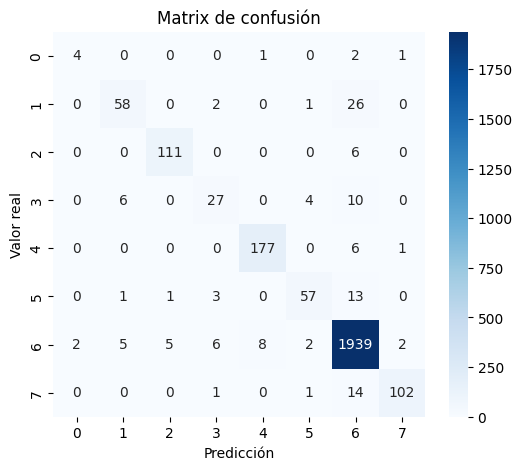

In [145]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'macro')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión')
plt.show()
